Loaded 12 configurations
    n_features config_label   auc_t+1   auc_t+2   auc_t+3
0           30       H=LB=3  0.763650  0.739905  0.741272
1           30    H=5, LB=3  0.757840  0.731553  0.731357
2           30       H=LB=5  0.761600  0.727698  0.729705
3           20       H=LB=3  0.758609  0.719714  0.733526
4           20    H=5, LB=3  0.756814  0.716777  0.725470
5           20       H=LB=5  0.756473  0.715675  0.726193
6           15       H=LB=3  0.758694  0.710811  0.730014
7           15    H=5, LB=3  0.754849  0.711087  0.725160
8           15       H=LB=5  0.748953  0.701909  0.717414
9           10       H=LB=3  0.727378  0.680020  0.712559
10          10    H=5, LB=3  0.720456  0.667539  0.696344
11          10       H=LB=5  0.715372  0.659783  0.677546

Saved → plots/spider_subgroupA_auc.png


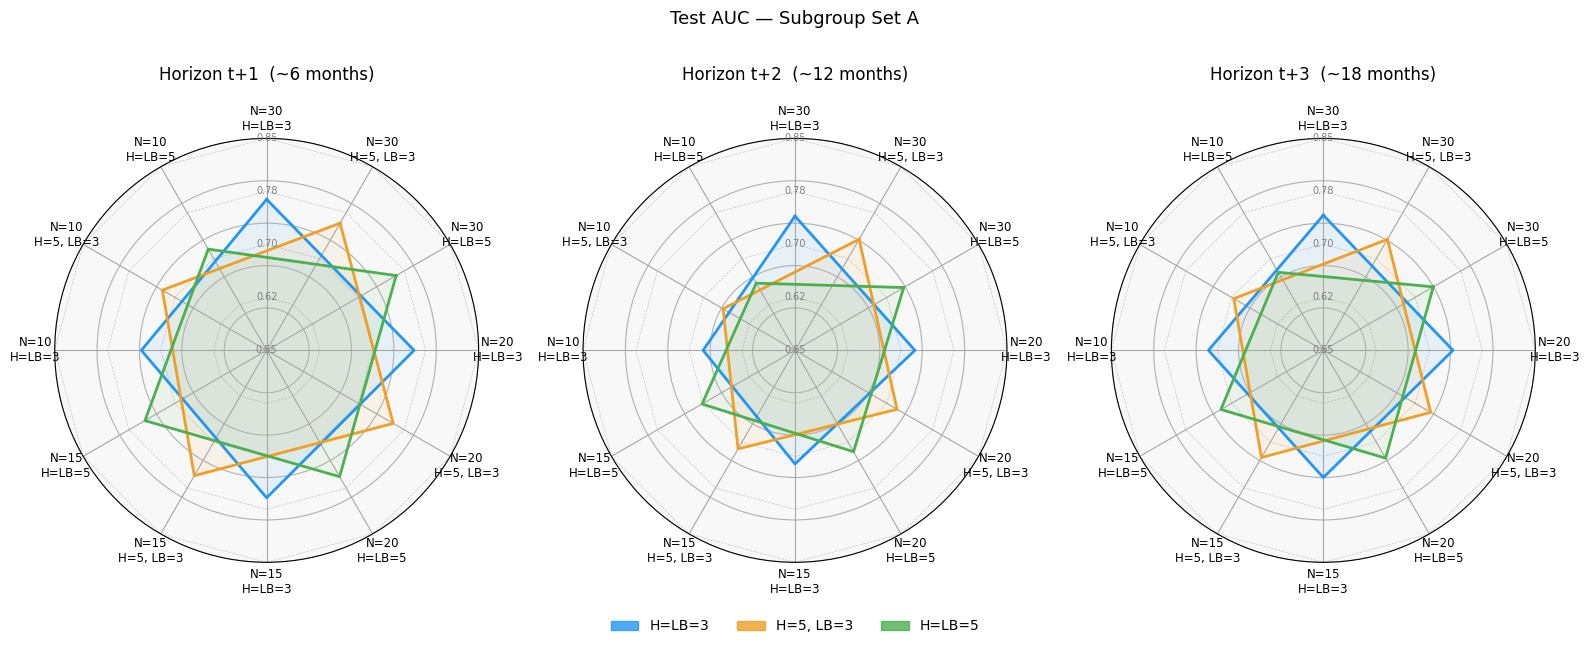

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import glob

# ── CONFIG ──────────────────────────────────────────────────────────────────
BASE_DIR    = Path("results")
OUTPUT_DIR  = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# Feature sizes and horizon/lookback configs to include
N_FEATURES  = [30, 20, 15, 10]
CONFIGS     = [
    ("H3_L3",  "H=LB=3"),
    ("H5_L3",  "H=5, LB=3"),
    ("H5_L5",  "H=LB=5"),
]

# Fixed suffix parts (everything after top{N}_{horizon_lookback})
FIXED_SUFFIX = "HS64_BS16_E50_P5_N1_D10"

# Colors per config
CONFIG_COLORS = {
    "H3_L3": "#2196F3",
    "H5_L3": "#EF9F27",
    "H5_L5": "#4CAF50",
}

# ── LOAD DATA ────────────────────────────────────────────────────────────────
records = []
for n in N_FEATURES:
    for cfg_key, cfg_label in CONFIGS:
        # Build expected filename pattern
        h, lb = cfg_key.split("_")
        h_num  = h.replace("H", "")
        lb_num = lb.replace("L", "")
        pattern = str(BASE_DIR / f"top{n}_{h_num}_{lb_num}_{FIXED_SUFFIX}" / f"metrics_summary_top{n}_H{h_num}_L{lb_num}_{FIXED_SUFFIX}.csv")

        matches = glob.glob(pattern)
        if not matches:
            # Try alternative pattern
            pattern2 = str(BASE_DIR / f"top{n}_H{h_num}_L{lb_num}_{FIXED_SUFFIX}" / f"metrics_summary_*.csv")
            matches = glob.glob(pattern2)

        if not matches:
            print(f"⚠️  Not found: top{n}, {cfg_label}")
            continue

        df = pd.read_csv(matches[0])
        test_row = df[df["split"] == "test"].iloc[0]

        records.append({
            "n_features": n,
            "config_key": cfg_key,
            "config_label": cfg_label,
            "label": f"N={n}\n{cfg_label}",
            "auc_t+1": test_row["auc_t+1"],
            "auc_t+2": test_row["auc_t+2"],
            "auc_t+3": test_row["auc_t+3"],
        })

if not records:
    print("No data found. Check BASE_DIR and file patterns.")
    exit()

df_all = pd.DataFrame(records)
print(f"Loaded {len(df_all)} configurations")
print(df_all[["n_features", "config_label", "auc_t+1", "auc_t+2", "auc_t+3"]])

# ── SPIDER PLOT FUNCTION ──────────────────────────────────────────────────────
def spider_plot(df, horizon, ax, title, vmin=0.55, vmax=0.85):
    categories = df["label"].tolist()
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the loop

    auc_col = f"auc_{horizon}"

    ax.set_facecolor("#F8F8F8")
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Grid rings
    n_rings = 5
    ring_vals = np.linspace(vmin, vmax, n_rings)
    for rv in ring_vals:
        scaled = (rv - vmin) / (vmax - vmin)
        ax.plot(angles, [scaled] * (N + 1), color="gray", linewidth=0.5, linestyle="--", alpha=0.4)
        ax.text(0, scaled, f"{rv:.2f}", ha="center", va="center",
                fontsize=7, color="gray", zorder=5)

    # Spoke lines
    for angle in angles[:-1]:
        ax.plot([angle, angle], [0, 1], color="gray", linewidth=0.4, alpha=0.3)

    # Plot per config
    for cfg_key, cfg_label in CONFIGS:
        sub = df[df["config_key"] == cfg_key]
        if sub.empty:
            continue
        color = CONFIG_COLORS[cfg_key]

        values = sub[auc_col].tolist()
        scaled = [(v - vmin) / (vmax - vmin) for v in values]
        scaled += scaled[:1]
        a = [angles[df.index.get_loc(i)] for i in sub.index] + [angles[df.index.get_loc(sub.index[0])]]

        ax.plot(a, scaled, color=color, linewidth=2, label=cfg_label)
        ax.fill(a, scaled, color=color, alpha=0.08)

    # Spoke labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=8.5)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight="500", pad=18)


# ── MAKE FIGURE ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6),
                         subplot_kw=dict(polar=True))
fig.suptitle("Test AUC — Subgroup Set A",
             fontsize=13, fontweight="500", y=1.02)

horizons = ["t+1", "t+2", "t+3"]
titles   = ["Horizon t+1  (~6 months)", "Horizon t+2  (~12 months)", "Horizon t+3  (~18 months)"]

for ax, h, title in zip(axes, horizons, titles):
    spider_plot(df_all, h, ax, title)

# Legend
handles = [mpatches.Patch(color=CONFIG_COLORS[k], label=v, alpha=0.8)
           for k, v in CONFIGS]
fig.legend(handles=handles, loc="lower center", ncol=3,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
out = OUTPUT_DIR / "spider_subgroupA_auc.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
print(f"\nSaved → {out}")
plt.show()

In [2]:
import glob
from pathlib import Path

# Juster til der filene dine faktisk ligger
base = Path("results")  # eller full sti

# Finn alle metrics_summary filer
all_files = glob.glob(str(base / "**" / "metrics_summary_*.csv"), recursive=True)
for f in sorted(all_files):
    print(f)

results/top10_H3_L3_HS64_BS16_E50_P5_N1_D10/metrics_summary_default_top10_H3_L3_HS64_BS16_E50_P5_N1_D10.csv
results/top10_H3_L3_HS64_BS16_E50_P5_N1_D10/metrics_summary_top10_H3_L3_HS64_BS16_E50_P5_N1_D10.csv
results/top10_H5_L3_HS64_BS16_E50_P5_N1_D10/metrics_summary_default_top10_H5_L3_HS64_BS16_E50_P5_N1_D10.csv
results/top10_H5_L3_HS64_BS16_E50_P5_N1_D10/metrics_summary_top10_H5_L3_HS64_BS16_E50_P5_N1_D10.csv
results/top10_H5_L5_HS64_BS16_E50_P5_N1_D10/metrics_summary_default_top10_H5_L5_HS64_BS16_E50_P5_N1_D10.csv
results/top10_H5_L5_HS64_BS16_E50_P5_N1_D10/metrics_summary_top10_H5_L5_HS64_BS16_E50_P5_N1_D10.csv
results/top15_H3_L3_HS64_BS16_E50_P5_N1_D10/metrics_summary_default_top15_H3_L3_HS64_BS16_E50_P5_N1_D10.csv
results/top15_H3_L3_HS64_BS16_E50_P5_N1_D10/metrics_summary_top15_H3_L3_HS64_BS16_E50_P5_N1_D10.csv
results/top15_H5_L3_HS64_BS16_E50_P5_N1_D10/metrics_summary_default_top15_H5_L3_HS64_BS16_E50_P5_N1_D10.csv
results/top15_H5_L3_HS64_BS16_E50_P5_N1_D10/metrics_summary_

Loaded 12 rows

     n  cfg_label   auc_t+1   auc_t+2   auc_t+3
0   30     H=LB=3  0.763650  0.739905  0.741272
1   30  H=5, LB=3  0.757840  0.731553  0.731357
2   30     H=LB=5  0.761600  0.727698  0.729705
3   20     H=LB=3  0.758609  0.719714  0.733526
4   20  H=5, LB=3  0.756814  0.716777  0.725470
5   20     H=LB=5  0.756473  0.715675  0.726193
6   15     H=LB=3  0.758694  0.710811  0.730014
7   15  H=5, LB=3  0.754849  0.711087  0.725160
8   15     H=LB=5  0.748953  0.701909  0.717414
9   10     H=LB=3  0.727378  0.680020  0.712559
10  10  H=5, LB=3  0.720456  0.667539  0.696344
11  10     H=LB=5  0.715372  0.659783  0.677546
Saved plot1_grouped_bar.png


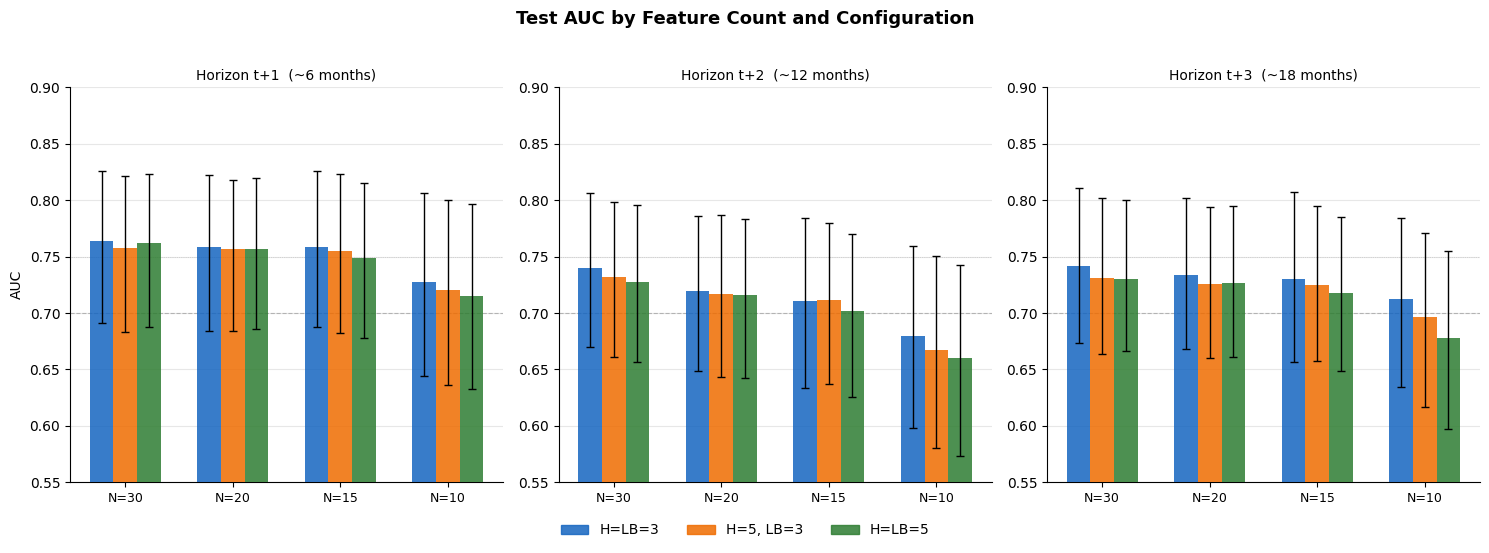

Saved plot2_line_trend.png


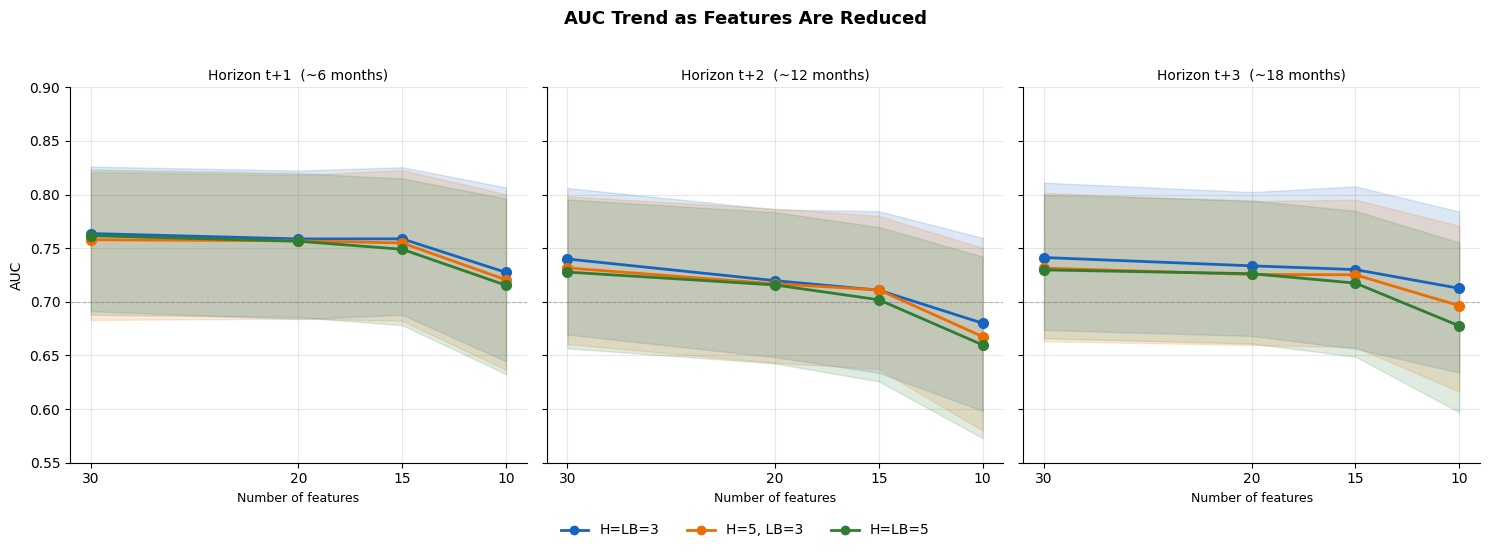

Saved plot3_heatmap.png


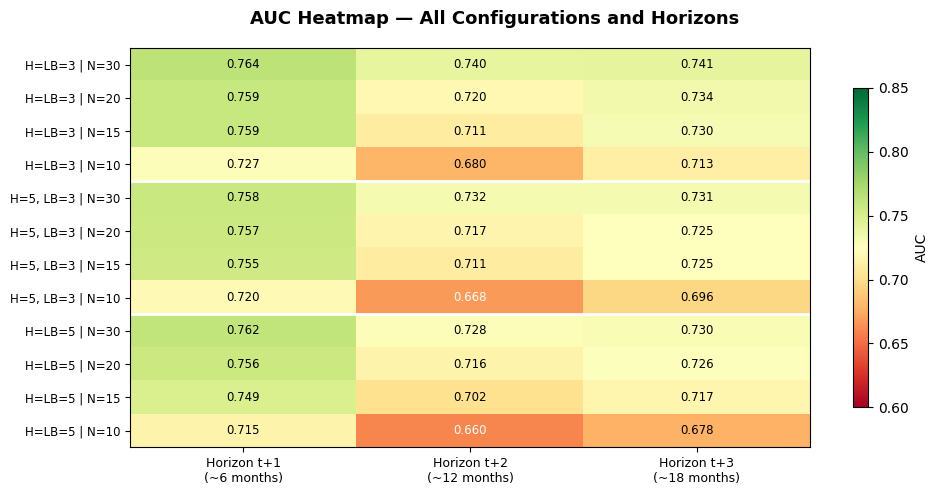

Saved plot4_multi_metric.png


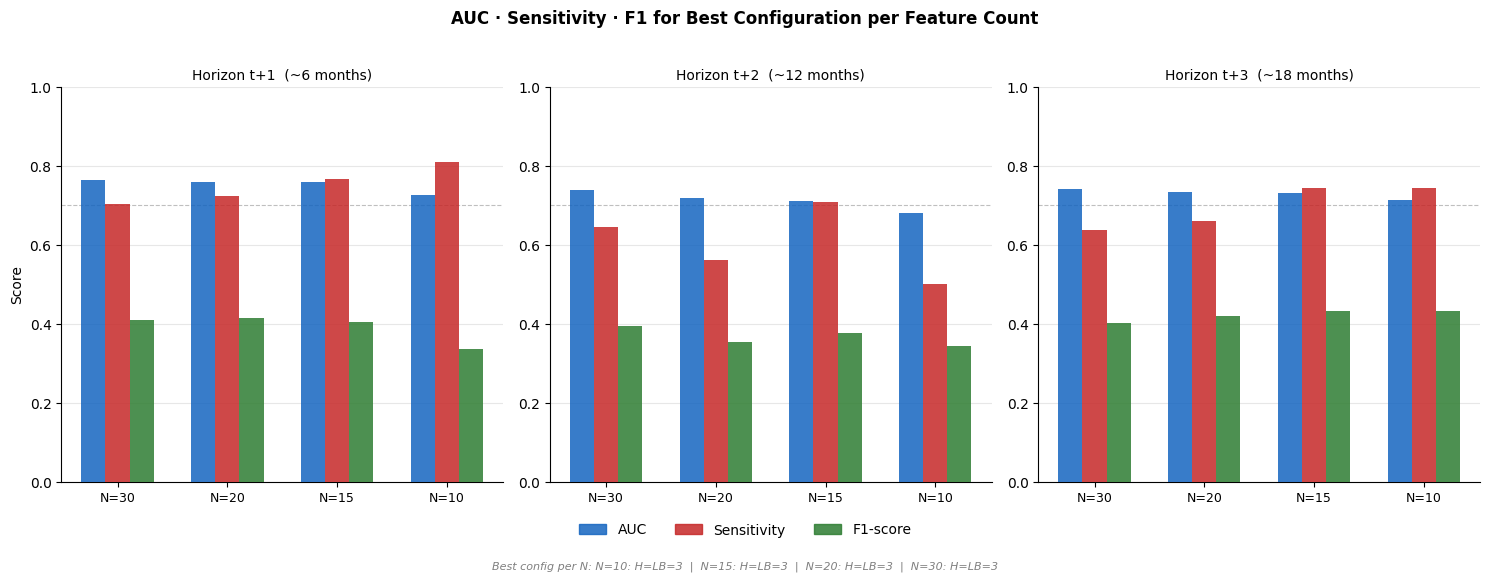


Done — all plots saved to: plots


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path
import glob

# ── CONFIG ───────────────────────────────────────────────────────────────────
BASE_DIR     = Path("results")
OUTPUT_DIR   = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)

N_FEATURES   = [30, 20, 15, 10]
CONFIGS      = [
    ("H3_L3", "H=LB=3",   "#1565C0"),
    ("H5_L3", "H=5, LB=3","#EF6C00"),
    ("H5_L5", "H=LB=5",   "#2E7D32"),
]
FIXED_SUFFIX = "HS64_BS16_E50_P5_N1_D10"
HORIZONS     = ["t+1", "t+2", "t+3"]
H_LABELS     = {"t+1": "~6 months", "t+2": "~12 months", "t+3": "~18 months"}

# ── LOAD ─────────────────────────────────────────────────────────────────────
records = []
for n in N_FEATURES:
    for cfg_key, cfg_label, color in CONFIGS:
        h_num  = cfg_key.split("_")[0].replace("H","")
        lb_num = cfg_key.split("_")[1].replace("L","")
        pattern = str(BASE_DIR / f"top{n}_H{h_num}_L{lb_num}_{FIXED_SUFFIX}" / "metrics_summary_*.csv")
        matches = glob.glob(pattern)
        if not matches:
            pattern2 = str(BASE_DIR / f"top{n}_{h_num}_{lb_num}_{FIXED_SUFFIX}" / "metrics_summary_*.csv")
            matches = glob.glob(pattern2)
        if not matches:
            print(f"⚠️  Not found: N={n}, {cfg_label}")
            continue
        df  = pd.read_csv(matches[0])
        row = df[df["split"]=="test"].iloc[0]
        rec = {"n": n, "cfg_key": cfg_key, "cfg_label": cfg_label, "color": color}
        for h in HORIZONS:
            rec[f"auc_{h}"]   = row[f"auc_{h}"]
            rec[f"ci_lo_{h}"] = row.get(f"ci_lo_{h}", np.nan)
            rec[f"ci_hi_{h}"] = row.get(f"ci_hi_{h}", np.nan)
            rec[f"sens_{h}"]  = row[f"sensitivity_{h}"]
            rec[f"f1_{h}"]    = row[f"f1_{h}"]
        records.append(rec)

if not records:
    print("No data found.")
    exit()

df_all = pd.DataFrame(records)
print(f"Loaded {len(df_all)} rows\n")
print(df_all[["n","cfg_label"] + [f"auc_{h}" for h in HORIZONS]])


# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Grouped bar chart: AUC per feature-size, grouped by config
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle("Test AUC by Feature Count and Configuration", fontsize=13, fontweight="bold", y=1.02)

bar_width = 0.22
x = np.arange(len(N_FEATURES))

for ax, h in zip(axes, HORIZONS):
    for i, (cfg_key, cfg_label, color) in enumerate(CONFIGS):
        sub = df_all[df_all["cfg_key"]==cfg_key].sort_values("n", ascending=False)
        aucs = sub[f"auc_{h}"].values
        lo   = sub[f"ci_lo_{h}"].values
        hi   = sub[f"ci_hi_{h}"].values
        err  = np.array([aucs - lo, hi - aucs])
        err  = np.where(np.isnan(err), 0, err)

        bars = ax.bar(x + (i - 1) * bar_width, aucs,
                      width=bar_width, color=color, alpha=0.85,
                      label=cfg_label, zorder=3)
        ax.errorbar(x + (i - 1) * bar_width, aucs,
                    yerr=err, fmt="none", color="black",
                    capsize=3, linewidth=1, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels([f"N={n}" for n in [30, 20, 15, 10]], fontsize=9)
    ax.set_ylim(0.55, 0.90)
    ax.set_ylabel("AUC" if h == "t+1" else "")
    ax.set_title(f"Horizon {h}  ({H_LABELS[h]})", fontsize=10)
    ax.axhline(0.7,  color="gray", linewidth=0.8, linestyle="--", alpha=0.5, label="_nolegend_")
    ax.axhline(0.75, color="gray", linewidth=0.5, linestyle=":", alpha=0.4, label="_nolegend_")
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles = [mpatches.Patch(color=c, label=l, alpha=0.85) for _, l, c in CONFIGS]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot1_grouped_bar.png", dpi=180, bbox_inches="tight")
print("Saved plot1_grouped_bar.png")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Line plot: AUC vs. N features (trend as features are reduced)
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("AUC Trend as Features Are Reduced", fontsize=13, fontweight="bold", y=1.02)

for ax, h in zip(axes, HORIZONS):
    for cfg_key, cfg_label, color in CONFIGS:
        sub = df_all[df_all["cfg_key"]==cfg_key].sort_values("n", ascending=False)
        ns   = sub["n"].values
        aucs = sub[f"auc_{h}"].values
        lo   = sub[f"ci_lo_{h}"].values
        hi   = sub[f"ci_hi_{h}"].values

        ax.plot(ns, aucs, marker="o", color=color, linewidth=2,
                markersize=7, label=cfg_label, zorder=3)
        if not np.all(np.isnan(lo)):
            ax.fill_between(ns, lo, hi, color=color, alpha=0.15, zorder=2)

    ax.set_xticks(N_FEATURES[::-1])
    ax.set_xticklabels([str(n) for n in N_FEATURES[::-1]])
    ax.set_xlabel("Number of features", fontsize=9)
    ax.set_ylabel("AUC" if h == "t+1" else "")
    ax.set_ylim(0.55, 0.90)
    ax.set_title(f"Horizon {h}  ({H_LABELS[h]})", fontsize=10)
    ax.axhline(0.7,  color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.invert_xaxis()   # 30 → 10 left to right = "reduction"

handles = [Line2D([0],[0], color=c, linewidth=2, marker="o", label=l)
           for _, l, c in CONFIGS]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot2_line_trend.png", dpi=180, bbox_inches="tight")
print("Saved plot2_line_trend.png")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Heatmap: AUC across all (N, config, horizon) combinations
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("AUC Heatmap — All Configurations and Horizons", fontsize=13, fontweight="bold")

row_labels = []
col_labels = [f"Horizon {h}\n({H_LABELS[h]})" for h in HORIZONS]
matrix     = []

for cfg_key, cfg_label, _ in CONFIGS:
    for n in N_FEATURES:
        row = df_all[(df_all["cfg_key"]==cfg_key) & (df_all["n"]==n)]
        if row.empty:
            matrix.append([np.nan]*3)
        else:
            matrix.append([row[f"auc_{h}"].values[0] for h in HORIZONS])
        row_labels.append(f"{cfg_label} | N={n}")

matrix = np.array(matrix)
vmin, vmax = 0.60, 0.85
im = ax.imshow(matrix, cmap="RdYlGn", vmin=vmin, vmax=vmax, aspect="auto")

ax.set_xticks(range(3))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8.5)

# Annotate cells
for i in range(len(row_labels)):
    for j in range(3):
        val = matrix[i, j]
        if not np.isnan(val):
            txt_color = "white" if (val < 0.67 or val > 0.80) else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=8.5, fontweight="500", color=txt_color)

# Separator lines between configs
for sep in [4, 8]:
    ax.axhline(sep - 0.5, color="white", linewidth=2)

plt.colorbar(im, ax=ax, label="AUC", shrink=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot3_heatmap.png", dpi=180, bbox_inches="tight")
print("Saved plot3_heatmap.png")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Multi-metric comparison: AUC + Sensitivity + F1 for best config
# ═══════════════════════════════════════════════════════════════════════════════
# Find best config per N based on mean AUC across horizons
df_all["mean_auc"] = df_all[[f"auc_{h}" for h in HORIZONS]].mean(axis=1)
best_per_n = df_all.loc[df_all.groupby("n")["mean_auc"].idxmax()]

metrics = ["auc", "sens", "f1"]
metric_labels = {"auc": "AUC", "sens": "Sensitivity", "f1": "F1-score"}
metric_colors = {"auc": "#1565C0", "sens": "#C62828", "f1": "#2E7D32"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle("AUC · Sensitivity · F1 for Best Configuration per Feature Count",
             fontsize=12, fontweight="bold", y=1.02)

bar_w = 0.22
x     = np.arange(len(N_FEATURES))

for ax, h in zip(axes, HORIZONS):
    for i, m in enumerate(metrics):
        vals = []
        for n in [30, 20, 15, 10]:
            row = best_per_n[best_per_n["n"]==n]
            vals.append(row[f"{m}_{h}"].values[0] if not row.empty else np.nan)

        ax.bar(x + (i-1)*bar_w, vals, width=bar_w,
               color=metric_colors[m], alpha=0.85, label=metric_labels[m], zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels([f"N={n}" for n in [30, 20, 15, 10]], fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score" if h == "t+1" else "")
    ax.set_title(f"Horizon {h}  ({H_LABELS[h]})", fontsize=10)
    ax.axhline(0.7, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles = [mpatches.Patch(color=metric_colors[m], label=metric_labels[m], alpha=0.85)
           for m in metrics]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.06))

# Add note about which config was best per N
note = "  |  ".join([f"N={r['n']}: {r['cfg_label']}" for _, r in best_per_n.iterrows()])
fig.text(0.5, -0.10, f"Best config per N: {note}", ha="center",
         fontsize=8, color="gray", style="italic")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plot4_multi_metric.png", dpi=180, bbox_inches="tight")
print("Saved plot4_multi_metric.png")
plt.show()

print("\nDone — all plots saved to:", OUTPUT_DIR)

In [ ]:
# I want you to find the results of the top30_H3_L3_HS64_BS16_E50_P5_N1_D10 for subgroup_setA/results, literature_baseline/results and univariate/results and plot them so they are comparable:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



Loaded comparison:
            source   auc_t+1   auc_t+2   auc_t+3
0    Feature set A  0.768350  0.760279  0.793328
1  Feature set B_1  0.763650  0.739905  0.741272
2  Feature set B_2  0.742630  0.709343  0.705020
3    Feature set C  0.758182  0.714299  0.720202
Saved -> plots/comparison_top30_H3_L3_colored.png


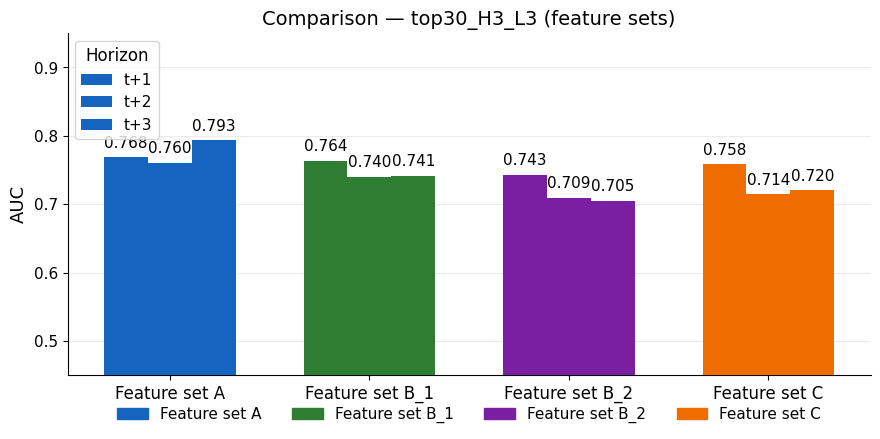

In [12]:
# --- Comparison for top30_H3_L3_HS64_BS16_E50_P5_N1_D10 across four result folders
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_DIRNAME = "top30_H3_L3_HS64_BS16_E50_P5_N1_D10"
SEARCH_BASES = [
    Path("../literature_baseline/results"),
    Path("../univariate/results"),
    Path("results"),
    Path("../subgroup_setB/results"),
]
# Naming used earlier
labels = ["Feature set A", "Feature set C", "Feature set B_1", "Feature set B_2"]

records = []
for base, label in zip(SEARCH_BASES, labels):
    candidate = base / TARGET_DIRNAME
    if not candidate.exists():
        found = None
        for p in base.glob("top30*H3*L3*HS64*_*"):
            if p.is_dir():
                found = p
                break
        if found:
            candidate = found
        else:
            print(f"⚠️  Not found: {TARGET_DIRNAME} under {base}")
            records.append({"source": label, "auc_t+1": np.nan, "auc_t+2": np.nan, "auc_t+3": np.nan})
            continue

    csvs = sorted(candidate.glob("metrics_summary_*.csv"))
    if not csvs:
        print(f"⚠️  No metrics_summary CSV in {candidate}")
        records.append({"source": label, "auc_t+1": np.nan, "auc_t+2": np.nan, "auc_t+3": np.nan})
        continue

    df = pd.read_csv(csvs[0])
    if "split" in df.columns and (df["split"] == "test").any():
        row = df[df["split"] == "test"].iloc[0]
    else:
        row = df.iloc[0]

    def get_val(col):
        return row[col] if col in row.index else (row.get(col.replace("_", ""), np.nan) if isinstance(row, pd.Series) else np.nan)

    records.append({
        "source": label,
        "auc_t+1": get_val("auc_t+1"),
        "auc_t+2": get_val("auc_t+2"),
        "auc_t+3": get_val("auc_t+3"),
    })

comp = pd.DataFrame(records)
# sort sources alphabetically for plotting
comp = comp.sort_values("source").reset_index(drop=True)

print("Loaded comparison:")
print(comp)

# Color mapping: literature_baseline -> blue (Feature set A), subgroup_setA -> orange (Feature set C)
color_map = {
    "Feature set A": "#1565C0",  # blue
    "Feature set C": "#EF6C00",  # orange
    "Feature set B_1": "#2E7D32",
    "Feature set B_2": "#7B1FA2",
}

horizons = ["t+1", "t+2", "t+3"]
x = np.arange(len(comp))
width = 0.22

# Plot with larger fonts
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, h in enumerate(horizons):
    vals = comp[f"auc_{h}"].astype(float).values
    colors = [color_map.get(s, "#777777") for s in comp["source"]]
    bars = ax.bar(x + (i-1)*width, vals, width=width, color=colors, label=h, zorder=3)
    # labels on bars
    for rect, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(
                rect.get_x() + rect.get_width()/2,
                rect.get_height() + 0.01,
                f"{val:.3f}",
                ha='center',
                va='bottom',
                fontsize=11,
            )

ax.set_xticks(x)
ax.set_xticklabels(comp["source"], rotation=0, fontsize=12)
ax.set_ylim(0.45, 0.95)
ax.set_ylabel("AUC", fontsize=13)
ax.set_title("Comparison — top30_H3_L3 (feature sets)", fontsize=14)
ax.grid(axis="y", alpha=0.25, zorder=0)
# enlarge ticks and spines
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend - show horizon labels and a separate legend for source colors
legend1 = ax.legend(title="Horizon", fontsize=11, title_fontsize=12, loc='upper left')
# create handles for source colors
from matplotlib.patches import Patch
handles = [Patch(color=color_map.get(s, "#777777"), label=s) for s in comp['source']]
legend2 = ax.legend(handles=handles, loc='lower center', ncol=len(handles), fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.18))
ax.add_artist(legend1)

plt.tight_layout()
out = OUTPUT_DIR / "comparison_top30_H3_L3_colored.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()

In [13]:
# --- Comparison plots for N=20 and N=15 (same config H3_L3 HS64...) and extended metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)

SEARCH_BASES = [Path("results"), Path("../literature_baseline/results"), Path("../univariate/results"), Path("../subgroup_setB/results")]
labels = ["subgroup_setA", "literature_baseline", "univariate", "subgroup_setB"]
CONFIG_SUFFIX = "HS64_BS16_E50_P5_N1_D10"
TARGET_H = "H3"
TARGET_L_LIST = ["L3", "L5"]

# metrics to produce plots for
metric_groups = [
    ("AUC", ["auc_t+1", "auc_t+2", "auc_t+3"]),
    ("Sensitivity", ["sensitivity_t+1", "sensitivity_t+2", "sensitivity_t+3"]),
    ("F1", ["f1_t+1", "f1_t+2", "f1_t+3"]),
    ("AP", ["ap_t+1", "ap_t+2", "ap_t+3"]),
]

# color mapping for sources (literature_baseline blue, subgroup_setA orange)
source_color = {
    "literature_baseline": "#1565C0",
    "subgroup_setA": "#EF6C00",
    "univariate": "#2E7D32",
    "subgroup_setB": "#7B1FA2",
}

# helper to load a folder candidate for topN, H, L
def find_candidate(base, topN, h, l):
    dirname = f"top{topN}_{h}_{l}_{CONFIG_SUFFIX}"
    candidate = base / dirname
    if candidate.exists():
        return candidate
    # tolerant search
    for p in base.glob(f"top{topN}*{h}*{l}*HS64*"):
        if p.is_dir():
            return p
    return None

# plot function for a given metric group and L (lookback)
def plot_metric_group(topN, L, metric_label, cols):
    records = []
    for base, label in zip(SEARCH_BASES, labels):
        candidate = find_candidate(base, topN, TARGET_H, L)
        if candidate is None:
            records.append({"source": label, **{c: np.nan for c in cols}})
            continue
        csvs = sorted(candidate.glob("metrics_summary_*.csv"))
        if not csvs:
            records.append({"source": label, **{c: np.nan for c in cols}})
            continue
        df = pd.read_csv(csvs[0])
        if "split" in df.columns and (df["split"] == "test").any():
            row = df[df["split"] == "test"].iloc[0]
        else:
            row = df.iloc[0]
        rec = {"source": label}
        for c in cols:
            rec[c] = row[c] if c in row.index else np.nan
        records.append(rec)
    comp = pd.DataFrame(records)
    comp = comp.sort_values("source").reset_index(drop=True)

    x = np.arange(len(comp))
    width = 0.22
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for i, c in enumerate(cols):
        vals = comp[c].astype(float).values
        colors = [source_color.get(s, "#777777") for s in comp["source"]]
        bars = ax.bar(x + (i-1)*width, vals, width=width, color=colors, label=c, zorder=3)
        for rect, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01, f"{val:.3f}", ha='center', va='bottom', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(comp["source"], rotation=0, fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(metric_label, fontsize=13)
    ax.set_title(f"{metric_label} — top{topN} {TARGET_H} {L}", fontsize=14)
    ax.grid(axis='y', alpha=0.25, zorder=0)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # legend for sources
    from matplotlib.patches import Patch
    handles = [Patch(color=source_color.get(s, "#777777"), label=s) for s in comp['source']]
    ax.legend(handles=handles, loc='lower center', ncol=len(handles), fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.18))

    plt.tight_layout()
    out = OUTPUT_DIR / f"top{topN}_{TARGET_H}_{L}_{metric_label.replace(' ', '_')}.png"
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved -> {out}")

# generate for N=30 and the two lookbacks
for L in TARGET_L_LIST:
    for metric_label, cols in metric_groups:
        plot_metric_group(30, L, metric_label, cols)

print('Done — all metric plots generated.')

Saved -> plots/top30_H3_L3_AUC.png
Saved -> plots/top30_H3_L3_Sensitivity.png
Saved -> plots/top30_H3_L3_F1.png
Saved -> plots/top30_H3_L3_AP.png
Saved -> plots/top30_H3_L5_AUC.png
Saved -> plots/top30_H3_L5_Sensitivity.png
Saved -> plots/top30_H3_L5_F1.png
Saved -> plots/top30_H3_L5_AP.png
Done — all metric plots generated.


Saved table CSV -> plots/selected_features_table_top30.csv


/var/folders/95/t78xg19j37g0pzlmfynn1p280000gn/T/ipykernel_18653/3006087515.py:114: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved table image -> plots/selected_features_table_top30.png


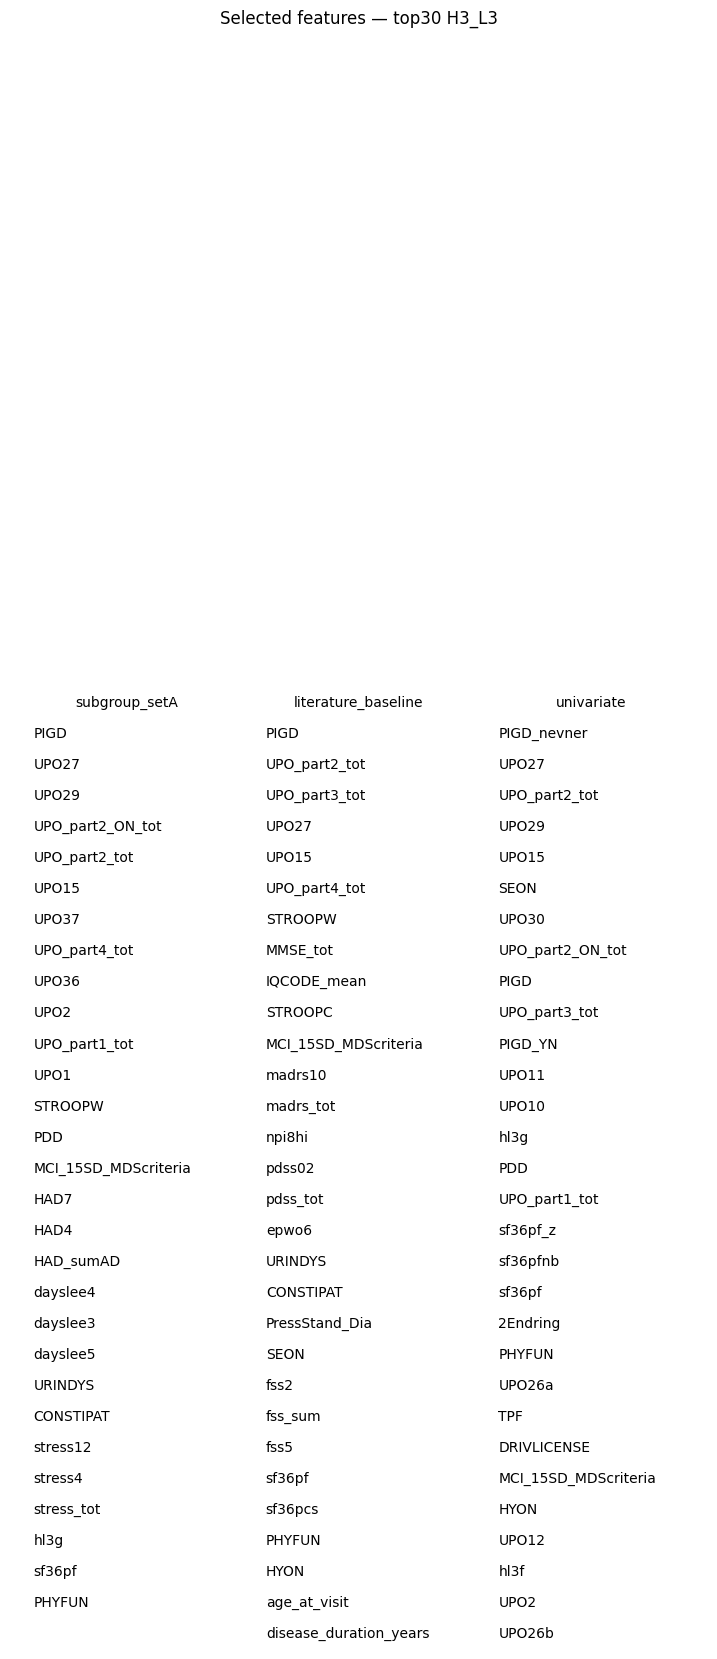

Done — selected-feature table created for N=30


In [15]:
# --- Read `selected_feature` files and make a clear table for N=30 only
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)

SEARCH_BASES = [Path("results"), Path("../literature_baseline/results"), Path("../univariate/results")]
labels = ["subgroup_setA", "literature_baseline", "univariate"]
TARGET_N = 30


def read_selected_features(folder):
    # look for the common exact filenames first
    candidates = [
        folder / "selected_features.csv",
        folder / "selected_feature.csv",
        folder / "selected_features.txt",
        folder / "selected_feature.txt",
    ]
    for p in candidates:
        if p.exists():
            try:
                if p.suffix.lower() == '.csv':
                    df = pd.read_csv(p, dtype=str, header=0)
                    # If single column, return values
                    if df.shape[1] == 1:
                        return df.iloc[:, 0].dropna().astype(str).tolist()
                    # look for a column name containing 'feature'
                    for col in df.columns:
                        if 'feature' in col.lower() or 'selected' in col.lower():
                            vals = df[col].dropna().astype(str).tolist()
                            if len(vals) == 1 and (',' in vals[0] or ';' in vals[0]):
                                sep = ',' if ',' in vals[0] else ';'
                                return [v.strip() for v in vals[0].split(sep) if v.strip()]
                            return [v.strip() for v in vals if v.strip()]
                    # fallback: flatten
                    return df.stack().dropna().astype(str).unique().tolist()
                else:
                    txt = p.read_text(encoding='utf-8')
                    lines = [l.strip() for l in txt.splitlines() if l.strip()]
                    if len(lines) == 1 and (',' in lines[0] or ';' in lines[0]):
                        sep = ',' if ',' in lines[0] else ';'
                        return [v.strip() for v in lines[0].split(sep) if v.strip()]
                    return lines
            except Exception:
                return None
    # fallback: search for any matching file
    for p in sorted(folder.glob('selected*')):
        try:
            if p.suffix.lower() == '.csv':
                df = pd.read_csv(p, dtype=str, header=0)
                if df.shape[1] == 1:
                    return df.iloc[:, 0].dropna().astype(str).tolist()
                for col in df.columns:
                    if 'feature' in col.lower() or 'selected' in col.lower():
                        return df[col].dropna().astype(str).tolist()
                return df.stack().dropna().astype(str).unique().tolist()
            else:
                txt = p.read_text(encoding='utf-8')
                lines = [l.strip() for l in txt.splitlines() if l.strip()]
                if len(lines) == 1 and (',' in lines[0] or ';' in lines[0]):
                    sep = ',' if ',' in lines[0] else ';'
                    return [v.strip() for v in lines[0].split(sep) if v.strip()]
                return lines
        except Exception:
            continue
    return None

# locate folder for N=30 in each base
tables = {}
for base, label in zip(SEARCH_BASES, labels):
    candidate = None
    for p in base.glob(f"top{TARGET_N}*H3*L3*HS64*"):
        if p.is_dir():
            candidate = p
            break
    if candidate is None:
        tables[label] = None
        print(f"⚠️  Not found folder for {label} under {base}")
        continue
    feats = read_selected_features(candidate)
    if feats is None:
        print(f"⚠️  No selected_feature file found in {candidate}")
    tables[label] = feats

# build a neat DataFrame with one column per source, padded
maxlen = max((len(v) if isinstance(v, (list,tuple)) else 0) for v in tables.values())
rows = {label: (tables[label] or []) + [""]*(maxlen - (len(tables[label]) if isinstance(tables[label], (list,tuple)) else 0))
        for label in labels}
df_table = pd.DataFrame(rows)

# save CSV
csv_out = OUTPUT_DIR / f"selected_features_table_top{TARGET_N}.csv"
df_table.to_csv(csv_out, index=False)
print(f"Saved table CSV -> {csv_out}")

# Render as image with larger font and column widths for readability
fig_w = 3 * len(labels)
fig_h = max(2.5, 0.28 * maxlen)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis('off')
# use matplotlib table
tbl = ax.table(cellText=df_table.values, colLabels=df_table.columns, cellLoc='left', colLoc='center')
for key, cell in tbl.get_celld().items():
    cell.set_edgecolor('none')
    cell.set_height(0.03)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
ax.set_title(f"Selected features — top{TARGET_N} H3_L3", pad=12)
out_img = OUTPUT_DIR / f"selected_features_table_top{TARGET_N}.png"
plt.tight_layout()
plt.savefig(out_img, dpi=200, bbox_inches='tight')
print(f"Saved table image -> {out_img}")
plt.show()

print('Done — selected-feature table created for N=30')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=242d6cfbd43e7487b7b6dbac694b069a16b64f8bbbde722155fde3562201f5c7
  Stored in directory: /Users/alanlici/Library/Caches/pip/wheels/c2/47/0c/f014c55a1cfd56dce41a1cafd23e3c590652b5e71330cc181c
Successfully built matplotlib-venn

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
subgroup_setA features (29): {'PHYFUN', 'stress4', 'HAD7', 'UPO15', 'UPO_part4_tot', 'STROOPW', 'dayslee5', 'stress_tot', 'PDD', 'HAD4', 'hl3g', 'URINDYS', 'stress12', 'UPO37', 'PIGD', 'UPO_part1_tot', 'MCI_15SD_MDScriteria', 'sf36pf', 'UPO36', 'UPO2', 'UPO1', 'CONSTIPAT', 'UPO27', 'UPO_part2_ON_tot', 'HAD_sumAD', 'dayslee4', 'UPO29', 'dayslee3', 'UPO_part

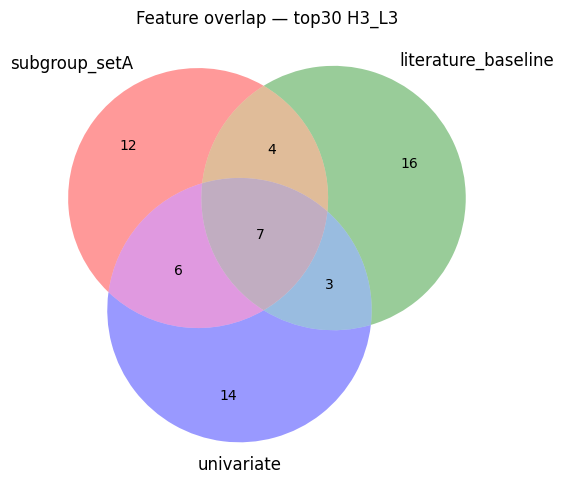

Done — Venn diagram created for feature overlap.


In [6]:
%pip install matplotlib-venn

## Generate a Venn diagram of feature overlap for the three sources (subgroup_setA, literature_baseline, univariate) for N=30
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from pathlib import Path  
import pandas as pd

OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)
SEARCH_BASES = [Path("results"), Path("../literature_baseline/results"), Path("../univariate/results")]
labels = ["subgroup_setA", "literature_baseline", "univariate"]
TARGET_N = 30
def read_features(folder):
    candidates = [
        folder / "selected_features.csv",
        folder / "selected_feature.csv",
        folder / "selected_features.txt",
        folder / "selected_feature.txt",
    ]
    for p in candidates:
        if p.exists():
            try:
                if p.suffix.lower() == '.csv':
                    df = pd.read_csv(p, dtype=str, header=0)
                    if df.shape[1] == 1:
                        return set(df.iloc[:, 0].dropna().astype(str).str.strip())
                    for col in df.columns:
                        if 'feature' in col.lower() or 'selected' in col.lower():
                            return set(df[col].dropna().astype(str).str.strip())
                    return set(df.stack().dropna().astype(str).str.strip())
                else:
                    txt = p.read_text(encoding='utf-8')
                    lines = [l.strip() for l in txt.splitlines() if l.strip()]
                    if len(lines) == 1 and (',' in lines[0] or ';' in lines[0]):
                        sep = ',' if ',' in lines[0] else ';'
                        return set(v.strip() for v in lines[0].split(sep) if v.strip())
                    return set(lines)
            except Exception:
                return set()
    # fallback: search for any matching file
    for p in sorted(folder.glob('selected*')):
        try:
            if p.suffix.lower() == '.csv':
                df = pd.read_csv(p, dtype=str, header=0)
                if df.shape[1] == 1:
                    return set(df.iloc[:, 0].dropna().astype(str).str.strip())
                for col in df.columns:
                    if 'feature' in col.lower() or 'selected' in col.lower():
                        return set(df[col].dropna().astype(str).str.strip())
                return set(df.stack().dropna().astype(str).str.strip())
            else:
                txt = p.read_text(encoding='utf-8')
                lines = [l.strip() for l in txt.splitlines() if l.strip()]
                if len(lines) == 1 and (',' in lines[0] or ';' in lines[0]):
                    sep = ',' if ',' in lines[0] else ';'
                    return set(v.strip() for v in lines[0].split(sep) if v.strip())
                return set(lines)
        except Exception:
            continue
    return set()
feature_sets = {}
for base, label in zip(SEARCH_BASES, labels):
    candidate = None
    for p in base.glob(f"top{TARGET_N}*H3*L3*HS64*"):
        if p.is_dir():
            candidate = p
            break
    if candidate is None:
        feature_sets[label] = set()
        print(f"⚠️  Not found folder for {label} under {base}")
        continue
    feats = read_features(candidate)
    feature_sets[label] = feats
    print(f"{label} features ({len(feats)}): {feats}")
plt.figure(figsize=(6, 6))
venn3(subsets=(feature_sets[labels[0]], feature_sets[labels[1]], feature_sets[labels[2]]),
      set_labels=labels)
plt.title(f"Feature overlap — top{TARGET_N} H3_L3")
out_venn = OUTPUT_DIR / f"feature_venn_top{TARGET_N}.png"
plt.savefig(out_venn, dpi=180, bbox_inches='tight')
print(f"Saved Venn diagram -> {out_venn}")
plt.show()
print("Done — Venn diagram created for feature overlap.")

In [9]:
# Create a table of all the top30 with H3 and L3 runs in the literature_baseline, including AUC, Sensitivity, and F1.
import pandas as pd
from pathlib import Path
OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)
SEARCH_BASE = Path("../literature_baseline/results")
records = []
for p in SEARCH_BASE.glob("top30*H3*L3*E50*_*"):
    if p.is_dir():
        csvs = sorted(p.glob("metrics_summary_*.csv"))
        if not csvs:
            print(f"⚠️  No metrics_summary CSV in {p}")
            continue
        df = pd.read_csv(csvs[0])
        if "split" in df.columns and (df["split"] == "test").any():
            row = df[df["split"] == "test"].iloc[0]
        else:
            row = df.iloc[0]
        def gv(col):
            return row[col] if col in row.index else np.nan
        records.append({
            "folder": p.name,
            "auc_t+1": gv("auc_t+1"),
            "auc_t+2": gv("auc_t+2"),
            "auc_t+3": gv("auc_t+3"),
            "sensitivity_t+1": gv("sensitivity_t+1"),
            "sensitivity_t+2": gv("sensitivity_t+2"),
            "sensitivity_t+3": gv("sensitivity_t+3"),
            "specificity_t+1": gv("specificity_t+1"),
            "specificity_t+2": gv("specificity_t+2"),
            "specificity_t+3": gv("specificity_t+3"),
            "f1_t+1": gv("f1_t+1"),
            "f1_t+2": gv("f1_t+2"),
            "f1_t+3": gv("f1_t+3"),
        })
df_lit = pd.DataFrame(records)
csv_out = OUTPUT_DIR / "literature_baseline_top30_H3_L3_metrics.csv"
df_lit.to_csv(csv_out, index=False)

Loaded 4 rows for subgroup_setA / H3_L3
Loaded 4 rows for subgroup_setA / H3_L5
Loaded 4 rows for literature_baseline / H3_L3
Loaded 4 rows for literature_baseline / H3_L5
Loaded 4 rows for univariate / H3_L3
Loaded 4 rows for univariate / H3_L5
Saved -> plots/comparison_auc_split_by_config_bestonly.png


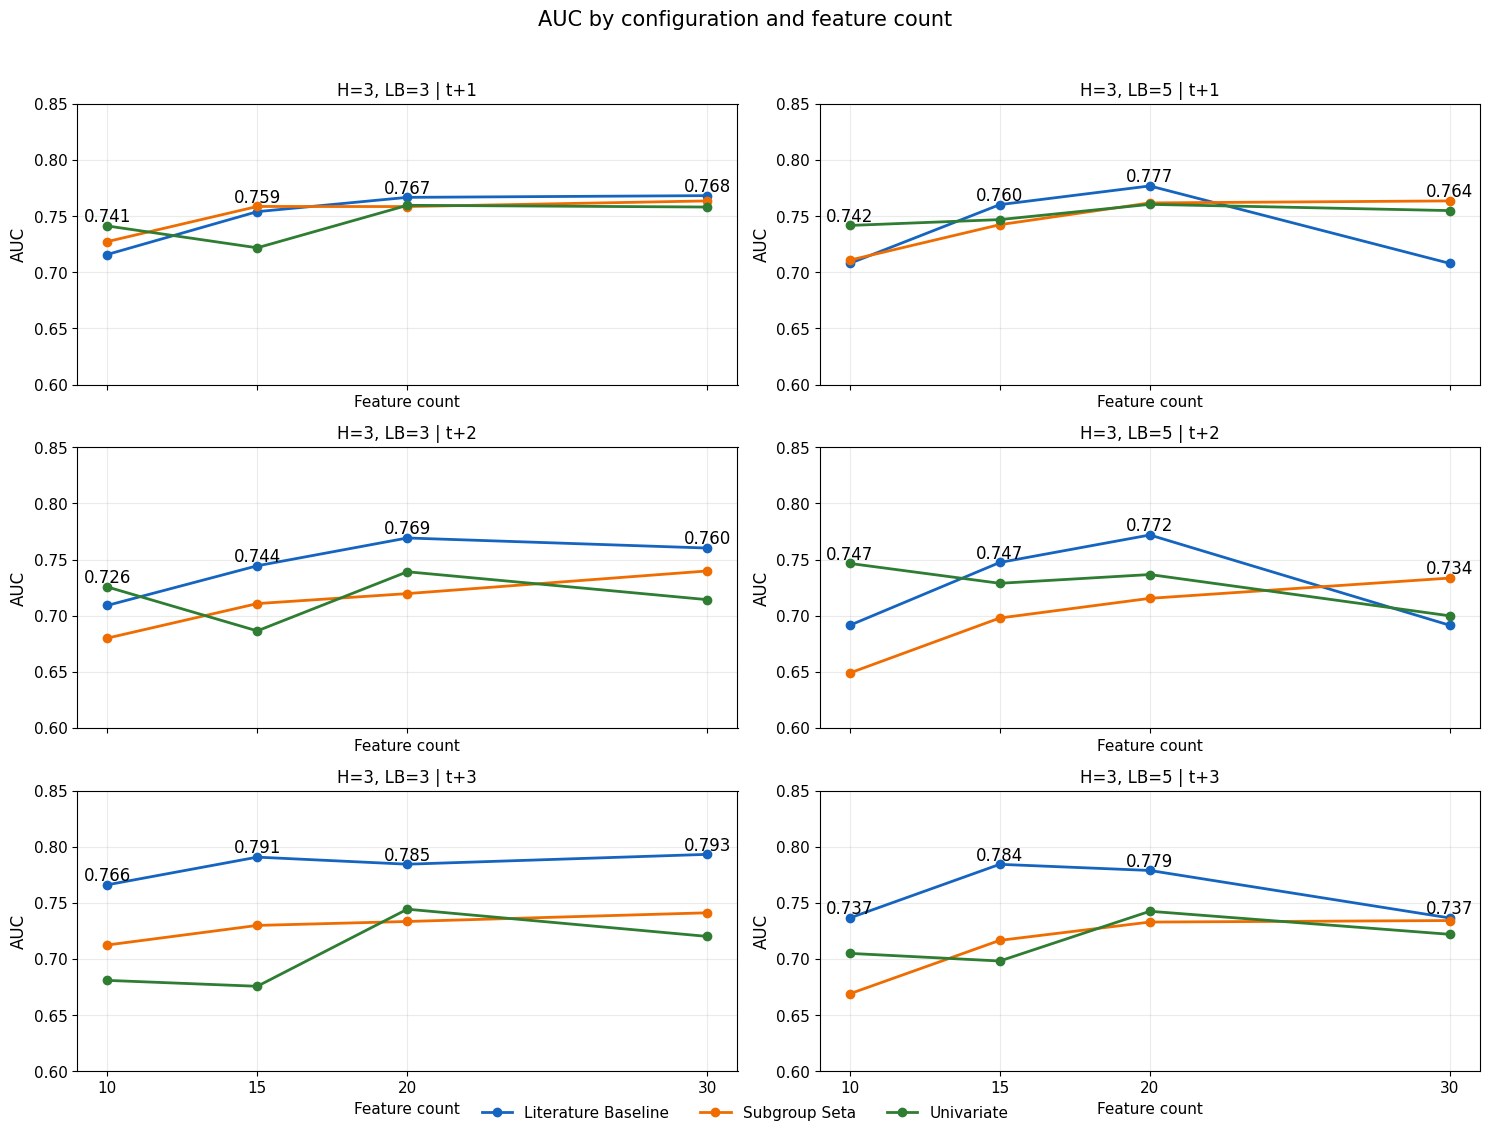

Saved -> plots/comparison_ap_split_by_config_bestonly.png


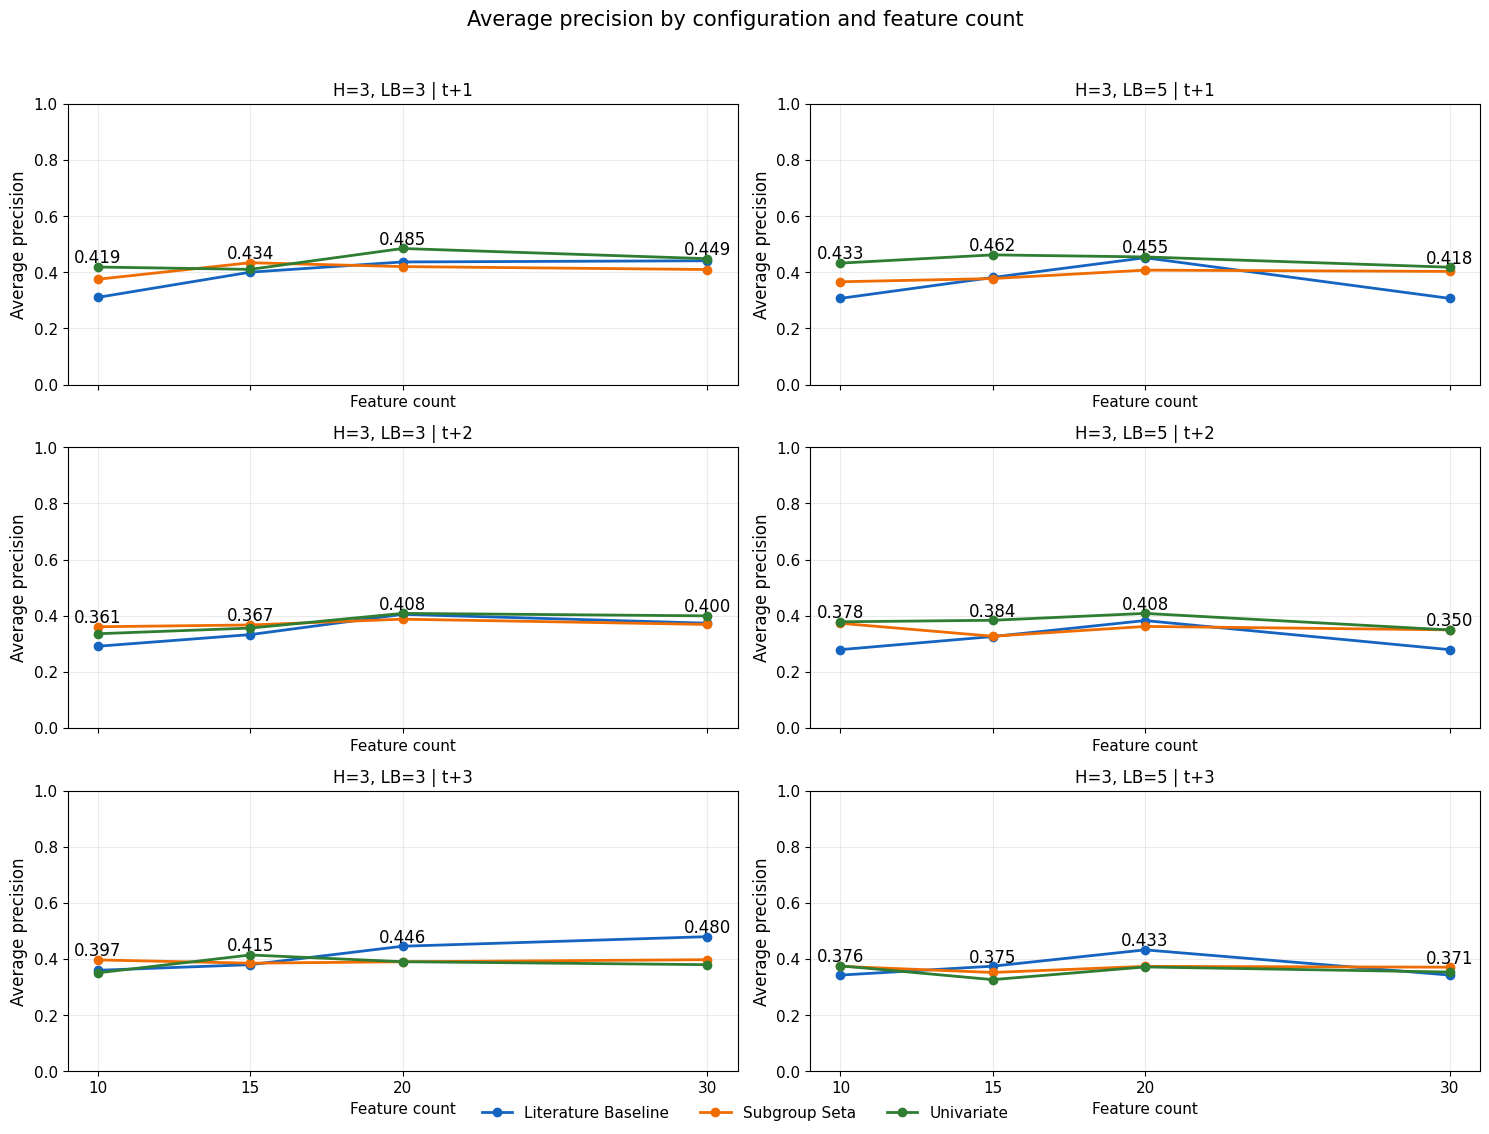

Saved -> plots/comparison_sensitivity_split_by_config_bestonly.png


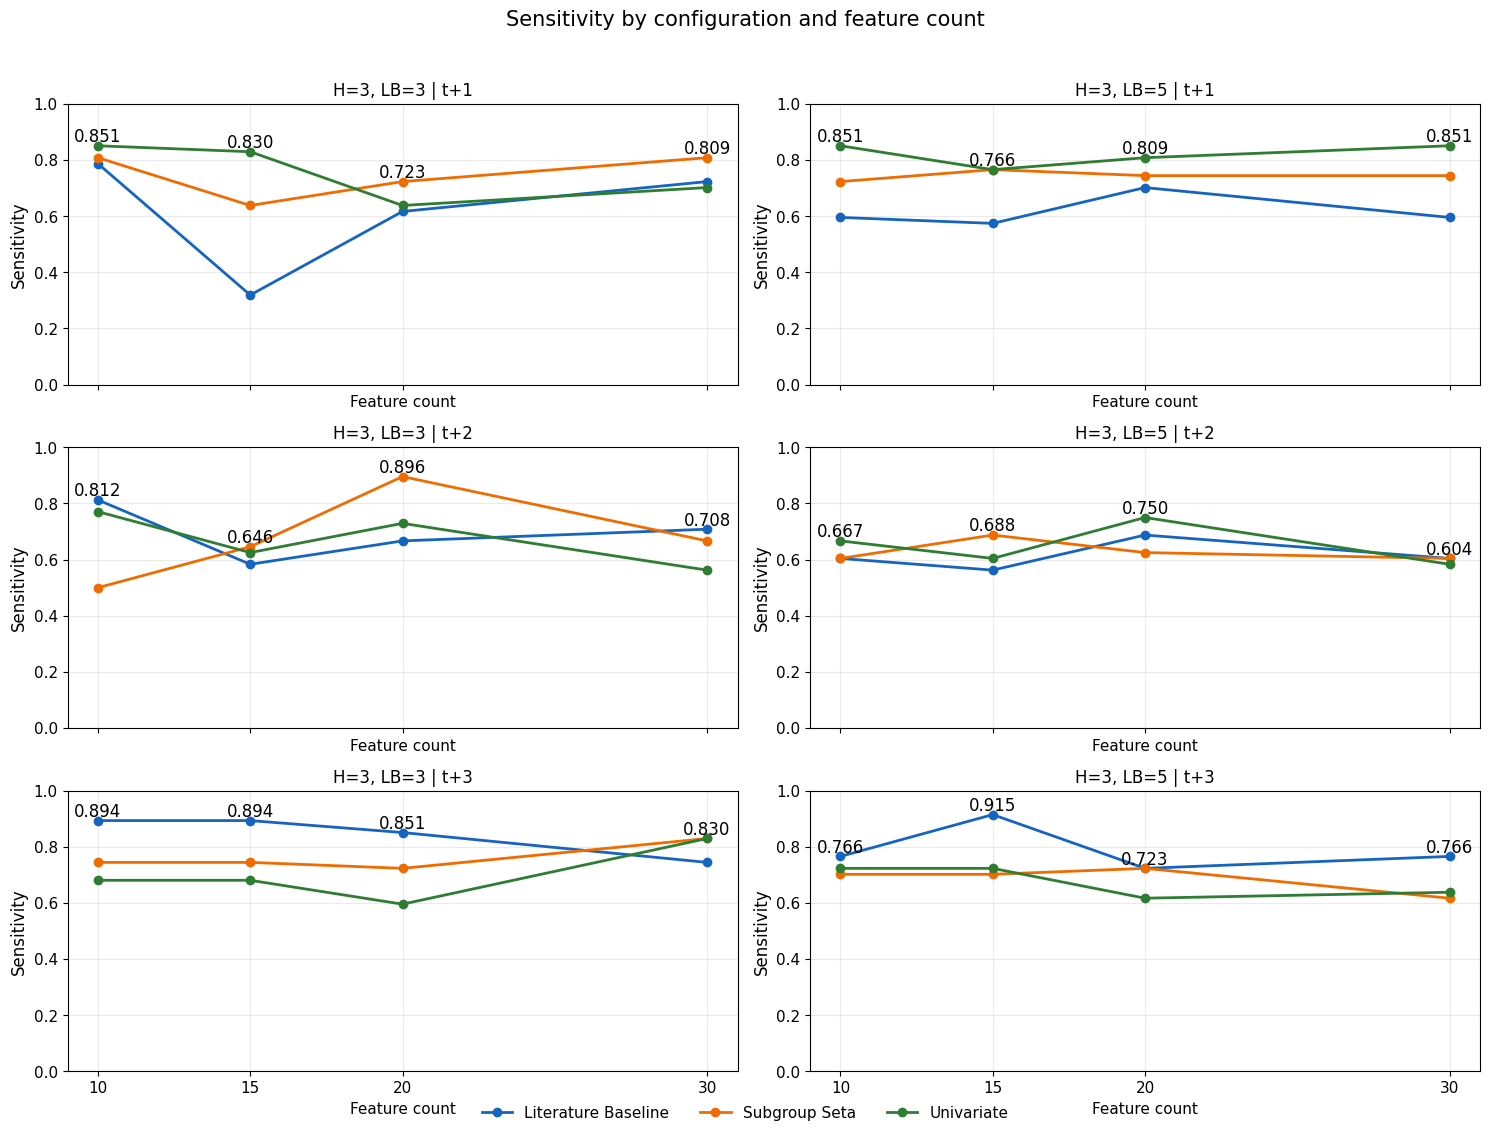

Saved -> plots/comparison_specificity_split_by_config_bestonly.png


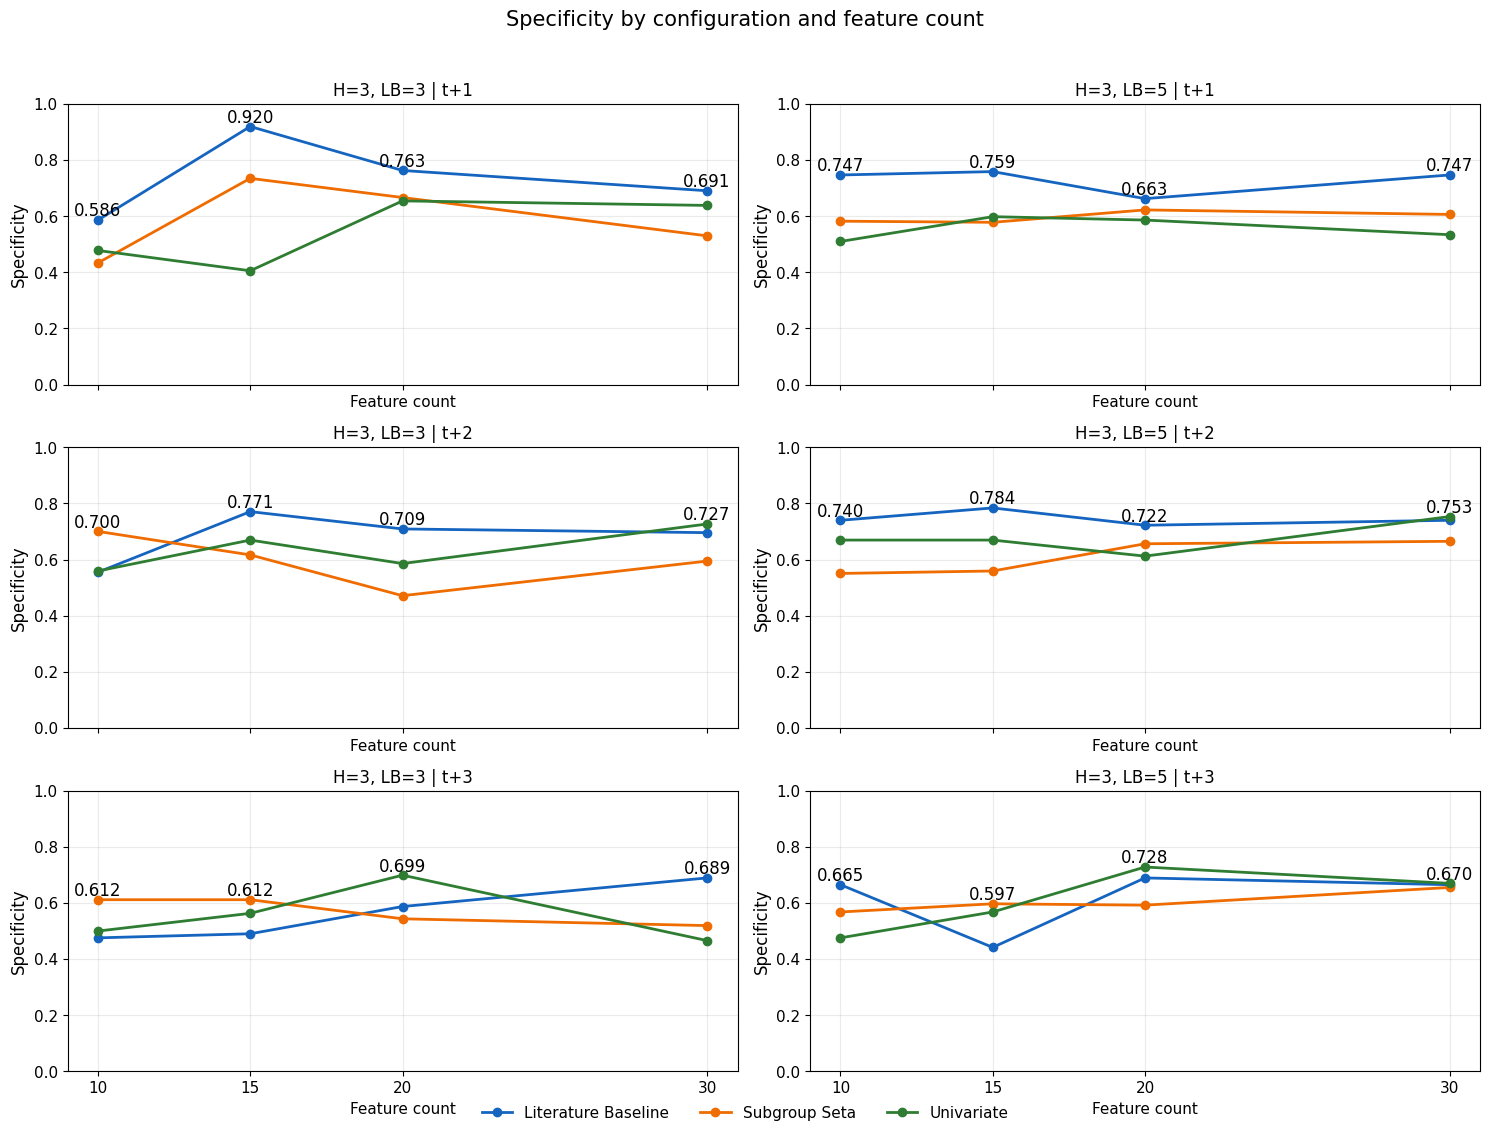

Saved -> plots/comparison_f1_split_by_config_bestonly.png


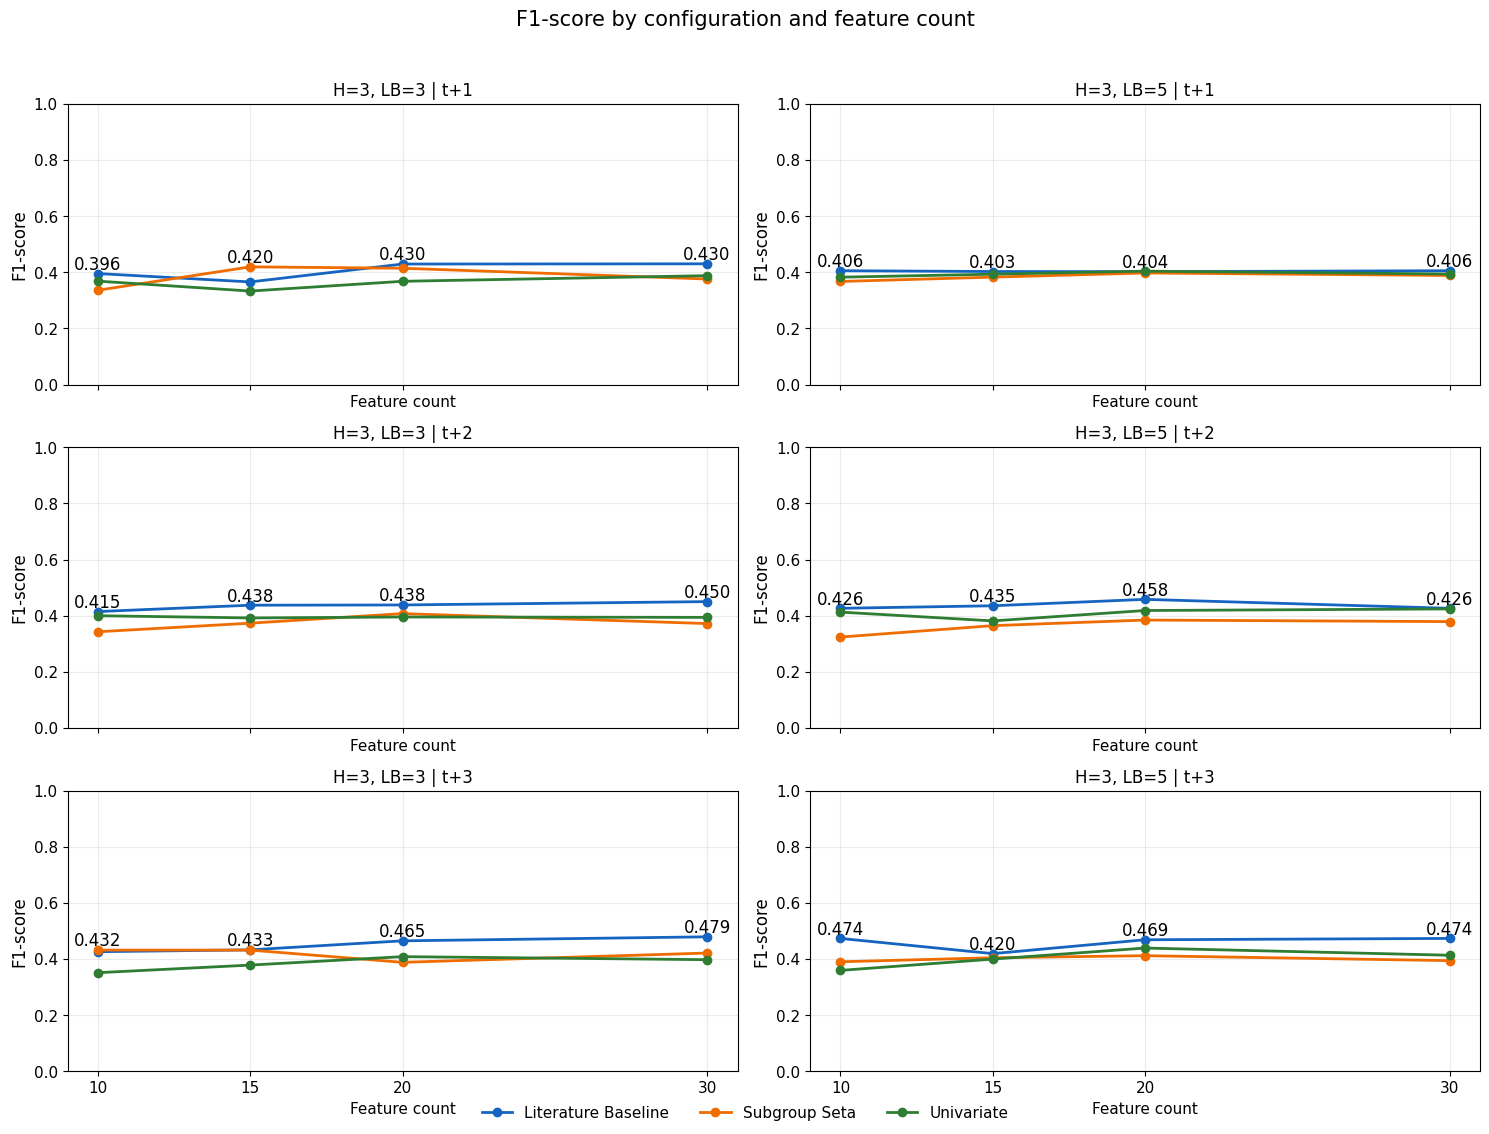

Done — split comparison plots created for each metric family (best per feature count annotated).


In [16]:
# Split comparison plots by configuration and metric family
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)

SEARCH_BASES = {
    "subgroup_setA": Path("results"),
    "literature_baseline": Path("../literature_baseline/results"),
    "univariate": Path("../univariate/results"),
}

CONFIGS = [
    ("H3_L3", "H=3, LB=3"),
    ("H3_L5", "H=3, LB=5"),
]

HORIZONS = ["t+1", "t+2", "t+3"]
N_VALUES = [10, 15, 20, 30]
# Swapped colors so literature_baseline is blue and subgroup_setA is orange
SOURCE_COLORS = {
    "subgroup_setA": "#EF6C00",
    "literature_baseline": "#1565C0",
    "univariate": "#2E7D32",
}

METRICS = {
    "auc": "AUC",
    "ap": "Average precision",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "f1": "F1-score",
}


def find_metrics_file(folder: Path):
    csvs = sorted(folder.glob("metrics_summary_top*.csv"))
    if not csvs:
        csvs = sorted(folder.glob("metrics_summary_*.csv"))
    return csvs[0] if csvs else None


def load_run_table(base: Path, cfg_key: str) -> pd.DataFrame:
    records = []
    for n in N_VALUES:
        folder = base / f"top{n}_{cfg_key}_HS64_BS16_E50_P5_N1_D10"
        if not folder.exists():
            matches = sorted(base.glob(f"top{n}_{cfg_key}_HS64_BS16_E50_P5_N1_D10*"))
            folder = matches[0] if matches else None
        if folder is None or not folder.exists():
            continue

        metrics_file = find_metrics_file(folder)
        if metrics_file is None:
            print(f"⚠️  No metrics_summary_top*.csv found in {folder}")
            continue

        df = pd.read_csv(metrics_file)
        if "split" in df.columns and (df["split"] == "test").any():
            row = df[df["split"] == "test"].iloc[0]
        else:
            row = df.iloc[0]

        record = {"n": n, "folder": folder.name, "source": base.name}
        for h in HORIZONS:
            for metric in METRICS:
                col = f"{metric}_{h}"
                record[col] = row[col] if col in row.index else np.nan
        records.append(record)

    return pd.DataFrame(records)


# Load tables for each source/config pair.
loaded = {}
for source, base in SEARCH_BASES.items():
    for cfg_key, _ in CONFIGS:
        table = load_run_table(base, cfg_key)
        loaded[(source, cfg_key)] = table
        if not table.empty:
            print(f"Loaded {len(table)} rows for {source} / {cfg_key}")


# small helper to make legend labels prettier
def display_name(source_key: str) -> str:
    return source_key.replace("_", " ").title()


def plot_metric(metric_key: str, metric_label: str):
    # annotation font size (increased)
    ann_fs = 12

    fig, axes = plt.subplots(
        nrows=len(HORIZONS),
        ncols=len(CONFIGS),
        figsize=(15, 11),
        sharex=True,
        sharey=False,
    )

    for col, (cfg_key, cfg_label) in enumerate(CONFIGS):
        for row, h in enumerate(HORIZONS):
            ax = axes[row, col]

            # gather y-values for all sources first so we can determine the best per feature count
            y_by_source = {}
            x = None
            for source in sorted(SEARCH_BASES.keys()):
                table = loaded.get((source, cfg_key), pd.DataFrame())
                if table.empty:
                    continue
                sub = table.sort_values("n")
                if x is None:
                    x = sub["n"].to_numpy()
                colname = f"{metric_key}_{h}"
                if colname not in sub.columns:
                    y = np.full(len(x), np.nan, dtype=float)
                else:
                    y = sub[colname].to_numpy(dtype=float)
                y_by_source[source] = y

            if x is None:
                # no data for this subplot
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"{cfg_label} | {h}", fontsize=12)
                continue

            # compute best source index per x (feature count), ignoring NaNs
            # best_map[xi] = source_key (or None)
            best_map = {}
            for xi in range(len(x)):
                best_src = None
                best_val = -np.inf
                for src, y in y_by_source.items():
                    val = y[xi]
                    if np.isnan(val):
                        continue
                    if val > best_val:
                        best_val = val
                        best_src = src
                best_map[xi] = best_src

            # plot each source's line and annotate only if it's the best for that x
            for src in sorted(SEARCH_BASES.keys()):
                if src not in y_by_source:
                    continue
                y = y_by_source[src]
                if np.all(np.isnan(y)):
                    continue
                ax.plot(
                    x,
                    y,
                    marker="o",
                    linewidth=2,
                    color=SOURCE_COLORS.get(src, "#777777"),
                    label=display_name(src) if (row == 0 and col == 0) else None,
                )
                for xi, (xv, yv) in enumerate(zip(x, y)):
                    if np.isnan(yv):
                        continue
                    # annotate only when this source is the best at this feature count
                    if best_map.get(xi) == src:
                        ax.text(xv, yv, f"{yv:.3f}", fontsize=ann_fs, ha="center", va="bottom")

            ax.set_title(f"{cfg_label} | {h}", fontsize=12)
            ax.set_xticks(N_VALUES)
            ax.set_xlabel("Feature count", fontsize=11)
            ax.set_ylabel(metric_label, fontsize=12)
            ax.grid(alpha=0.25)
            # set tighter y-limits for AUC to highlight differences
            if metric_key == "auc":
                ax.set_ylim((0.6, 0.85))
            else:
                ax.set_ylim((0.0, 1.0))

            ax.tick_params(axis='y', labelsize=11)
            ax.tick_params(axis='x', labelsize=11)

    # build legend handles in alphabetical order of sources
    handles = [
        plt.Line2D([0], [0], color=SOURCE_COLORS.get(s, "#777777"), marker="o", linewidth=2, label=display_name(s))
        for s in sorted(SEARCH_BASES.keys())
    ]
    fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, fontsize=11)
    fig.suptitle(f"{metric_label} by configuration and feature count", fontsize=15, y=1.02)
    plt.tight_layout()

    out = OUTPUT_DIR / f"comparison_{metric_key}_split_by_config_bestonly.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    print(f"Saved -> {out}")
    plt.show()


for metric_key, metric_label in METRICS.items():
    plot_metric(metric_key, metric_label)

print("Done — split comparison plots created for each metric family (best per feature count annotated).")

In [22]:
# Build summary tables for each feature set across all N values and all horizons
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)

SEARCH_BASES = {
    "subgroup_setA": Path("results"),
    "literature_baseline": Path("../literature_baseline/results"),
    "univariate": Path("../univariate/results"),
    "subgroup_setB": Path("../subgroup_setB/results"),
}

CONFIGS = [
    ("H3_L3", "H=3, LB=3"),
    ("H3_L5", "H=3, LB=5"),
]

N_VALUES = [10, 15, 20, 30]
HORIZONS = ["t+1", "t+2", "t+3"]
METRIC_FIELDS = {
    "auc": "AUC",
    "ap": "AP",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "f1": "F1-Score",
}


def find_metrics_file(folder: Path):
    csvs = sorted(folder.glob("metrics_summary_top*.csv"))
    if not csvs:
        csvs = sorted(folder.glob("metrics_summary_*.csv"))
    return csvs[0] if csvs else None


def read_test_row(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    if "split" in df.columns and (df["split"] == "test").any():
        return df[df["split"] == "test"].iloc[0]
    return df.iloc[0]


def load_feature_table(base: Path, cfg_key: str) -> pd.DataFrame:
    rows = []
    for n in N_VALUES:
        folder = base / f"top{n}_{cfg_key}_HS64_BS16_E50_P5_N1_D10"
        if not folder.exists():
            matches = sorted(base.glob(f"top{n}_{cfg_key}_HS64_BS16_E50_P5_N1_D10*"))
            folder = matches[0] if matches else None
        if folder is None or not folder.exists():
            rows.append({"n_features": n, **{col: np.nan for col in []}})
            continue

        metrics_file = find_metrics_file(folder)
        if metrics_file is None:
            rows.append({"n_features": n})
            continue

        row = read_test_row(metrics_file)
        item = {"n_features": n}
        for horizon in HORIZONS:
            # AUC with CI
            item[f"AUC_{horizon}"] = row[f"auc_{horizon}"] if f"auc_{horizon}" in row.index else np.nan
            item[f"CI_lo_{horizon}"] = row[f"ci_lo_{horizon}"] if f"ci_lo_{horizon}" in row.index else np.nan
            item[f"CI_hi_{horizon}"] = row[f"ci_hi_{horizon}"] if f"ci_hi_{horizon}" in row.index else np.nan

            # Other metrics without CIs in the source CSV
            item[f"AP_{horizon}"] = row[f"ap_{horizon}"] if f"ap_{horizon}" in row.index else np.nan
            item[f"Sensitivity_{horizon}"] = row[f"sensitivity_{horizon}"] if f"sensitivity_{horizon}" in row.index else np.nan
            item[f"Specificity_{horizon}"] = row[f"specificity_{horizon}"] if f"specificity_{horizon}" in row.index else np.nan
            item[f"F1-Score_{horizon}"] = row[f"f1_{horizon}"] if f"f1_{horizon}" in row.index else np.nan

        rows.append(item)

    return pd.DataFrame(rows)


for source_name, base in SEARCH_BASES.items():
    for cfg_key, cfg_label in CONFIGS:
        table = load_feature_table(base, cfg_key)
        if table.empty:
            print(f"⚠️  No rows found for {source_name} / {cfg_key}")
            continue

        table = table.sort_values("n_features", ascending=False).reset_index(drop=True)
        out_csv = OUTPUT_DIR / f"summary_table_{source_name}_{cfg_key}.csv"
        table.to_csv(out_csv, index=False)
        print(f"Saved -> {out_csv}")
        print(f"{source_name.replace('_', ' ').title()} | {cfg_label}")
        display(table)

print("Done — summary tables created for each feature set and configuration.")

Saved -> plots/summary_table_PPMI_domain_H3_L3.csv
Ppmi Domain | H=3, LB=3


,n_features
0,30
1,20
2,15
3,10


Saved -> plots/summary_table_PPMI_domain_H3_L3.csv
Ppmi Domain | H=3, LB=3


,n_features
0,30
1,20
2,15
3,10


Saved -> plots/summary_table_PPMI_domain_H3_L5.csv
Ppmi Domain | H=3, LB=5


...

Saved -> plots/summary_table_PPMI_univariate_H3_L3.csv
Ppmi Univariate | H=3, LB=3


,n_features
0,30
1,20
2,15
3,10


Saved -> plots/summary_table_PPMI_univariate_H3_L5.csv
Ppmi Univariate | H=3, LB=5


,n_features
0,30
1,20
2,15
3,10


Done — summary tables created for each feature set and configuration.


In [ ]:
## do a summary table for the results in `PPMI_LSTM/results/PPMI_domain/results/top15_H3_L3_HS64_BS16_E55_P5_N1_D10` and the matching folders for `PPMI_Literature` and `PPMI_univariate`
import pandas as pd
from pathlib import Path
OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(exist_ok=True)
SEARCH_BASES = {
    "PPMI_domain": Path("../../PPMI_LSTM/results/PPMI_domain/results"),
    "PPMI_Literature": Path("../../PPMI_LSTM/results/PPMI_Literature/results"),
    "PPMI_univariate": Path("../../PPMI_LSTM/results/PPMI_univariate/results"),
}
CONFIG_KEY = "H3_L3"
N_VALUE = 15
RUN_SUFFIX = "HS64_BS16_E55_P5_N1_D10"
HORIZONS = ["t+1", "t+2", "t+3"]
METRIC_FIELDS = {
    "auc": "AUC",
    "ap": "AP",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "f1": "F1-Score",
}
def find_metrics_file(folder: Path):
    csvs = sorted(folder.glob("metrics_summary_top*.csv"))
    if not csvs:
        csvs = sorted(folder.glob("metrics_summary_*.csv"))
    return csvs[0] if csvs else None
def read_test_row(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    if "split" in df.columns and (df["split"] == "test").any():
        return df[df["split"] == "test"].iloc[0]
    return df.iloc[0]
def read_selected_features(folder: Path):
    selected_file = folder / "selected_features.csv"
    if not selected_file.exists():
        selected_file = folder / "selected_feature.csv"
    if not selected_file.exists():
        return None

    feat_df = pd.read_csv(selected_file)
    if feat_df.shape[1] == 1:
        return feat_df.iloc[:, 0].dropna().astype(str).tolist()

    feature_cols = [c for c in feat_df.columns if "feature" in c.lower() or "selected" in c.lower()]
    if feature_cols:
        vals = feat_df[feature_cols[0]].dropna().astype(str).tolist()
        return [v.strip() for v in vals if v.strip()]

    return feat_df.stack().dropna().astype(str).tolist()

records = []
feature_records = []
for source_name, base in SEARCH_BASES.items():
    folder = base / f"top{N_VALUE}_{CONFIG_KEY}_{RUN_SUFFIX}"
    if not folder.exists():
        matches = sorted(base.glob(f"top{N_VALUE}_{CONFIG_KEY}_{RUN_SUFFIX}*"))
        folder = matches[0] if matches else None
    if folder is None or not folder.exists():
        print(f"⚠️  Not found folder for {source_name} under {base}")
        continue

    metrics_file = find_metrics_file(folder)
    if metrics_file is None:
        print(f"⚠️  No metrics_summary CSV found in {folder}")
        continue

    row = read_test_row(metrics_file)
    item = {"source": source_name}
    for horizon in HORIZONS:
        item[f"AUC_{horizon}"] = row[f"auc_{horizon}"] if f"auc_{horizon}" in row.index else np.nan
        item[f"CI_lo_{horizon}"] = row[f"ci_lo_{horizon}"] if f"ci_lo_{horizon}" in row.index else np.nan
        item[f"CI_hi_{horizon}"] = row[f"ci_hi_{horizon}"] if f"ci_hi_{horizon}" in row.index else np.nan
        item[f"AP_{horizon}"] = row[f"ap_{horizon}"] if f"ap_{horizon}" in row.index else np.nan
        item[f"Sensitivity_{horizon}"] = row[f"sensitivity_{horizon}"] if f"sensitivity_{horizon}" in row.index else np.nan
        item[f"Specificity_{horizon}"] = row[f"specificity_{horizon}"] if f"specificity_{horizon}" in row.index else np.nan
        item[f"F1-Score_{horizon}"] = row[f"f1_{horizon}"] if f"f1_{horizon}" in row.index else np.nan
    records.append(item)

    selected_features = read_selected_features(folder)
    if selected_features is not None:
        for rank, feature_name in enumerate(selected_features, start=1):
            feature_records.append({
                "source": source_name,
                "rank": rank,
                "feature_name": feature_name,
            })

df_summary = pd.DataFrame(records)
out_csv = OUTPUT_DIR / f"summary_table_all_sources_PPMI{CONFIG_KEY}_top{N_VALUE}.csv"
df_summary.to_csv(out_csv, index=False)
print(f"Saved -> {out_csv}")

df_selected = pd.DataFrame(feature_records)
selected_out_csv = OUTPUT_DIR / f"selected_features_all_sources_PPMI{CONFIG_KEY}_top{N_VALUE}.csv"
df_selected.to_csv(selected_out_csv, index=False)
print(f"Saved -> {selected_out_csv}")


Saved -> plots/summary_table_all_sources_PPMIH3_L3_top15.csv
Saved -> plots/selected_features_all_sources_PPMIH3_L3_top15.csv
